# Prediction of Chronic Kidney Disease Using Clinical and Laboratory Data: Diagnostic vs Screening\-Oriented Modeling

This project will use the [Chronic Kidney Disease (CKD) Dataset](https://archive.ics.uci.edu/dataset/336/chronic+kidney+disease), publicly available from the UCI Machine Learning Repository. The dataset contains real clinical data collected from patients undergoing medical evaluation for kidney function and related conditions. It is fully tabular, open-source and non-synthetic.

The dataset consists of 400 records and includes 24 explanatory variables plus one outcome variable. Each observation corresponds to a single patient and includes demographic information (such as age and sex), physiological measurements (such as blood pressure), laboratory test results (e.g. serum creatinine, blood urea, hemoglobin, electrolytes), urine analysis indicators (e.g. albumin, specific gravity), and clinical history variables (such as the presence of diabetes mellitus, hypertension, anemia and edema). The outcome variable is a binary indicator of Chronic Kidney Disease status, specifying whether the patient has been diagnosed with CKD or not.

The purpose of this project is to address a supervised learning problem, primarly framed as a binary classification task, where the goal is to predict the presence of CKD based on the most relevant explanatory variables such as age, sex, laboratory tests and urine analysis indicators.

## Introduction

The kidneys are vital organs whose main function is to maintain the body's internal balance (homeostasis) by filtering the blood and regulating fluids, electrolytes, and hormones. CKD is a long-term condition in which the kidneys gradually lose their ability to filter blood properly. The damage is progressive and irreversible, and it develops over months or years.

The clinical diagnosis of CKD relies on a well-defined set of laboratory and clinical indicators including serum creatinine, urine albumin, urine specific gravity and markers of urinary tract infection, which directly reflect renal impairment and which are present in this dataset.

From a machine learning perspective, when such diagnostic variables are included among the predictors, the classification task becomes quasi-deterministic, as the model may learn established diagnostic rules rather than uncovering predictive patterns that generalize beyond clinical confirmation.

For this reason, this project frames two related but distinct supervised learning problems.
Firstly, it investigates whether machine learning models can accurately reproduce clinical CKD diagnoses when a complete set of diagnostic information (the whole dataset in our case) is available. In other words, assessing the achievability of automated diagnostic support.
Secondly, it evaluates model performance in a screening-oriented scenario, where prediction is based on more general demographic, physiological, and routinary laboratory test results excluding urine analysis indicators.

This dual framing allows us to both confirm the discriminative power of established clinical markers and to assess the limits of early CKD prediction in a realistic screening setting, where direct diagnostic measurements may not yet be available.

## Import Libraries

In [99]:
import pandas as pd
import numpy as np
import missingno as msno
import matplotlib.pyplot as plt
import seaborn as sns
import itertools
import math
import statsmodels
from matplotlib.colors import ListedColormap
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from imblearn.pipeline import Pipeline as IMBPipeline
from sklearn.metrics import f1_score, recall_score, precision_score, make_scorer, classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.feature_selection import SequentialFeatureSelector
from sklearn.model_selection import learning_curve, validation_curve, train_test_split, KFold, StratifiedKFold, cross_val_score, GridSearchCV, RandomizedSearchCV, cross_validate, RepeatedStratifiedKFold
from sklearn.linear_model import Perceptron, LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.decomposition import PCA
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA
from sklearn.ensemble import RandomForestClassifier
from scipy.stats import loguniform, beta, uniform, zscore, randint
from imblearn.over_sampling import SMOTE, RandomOverSampler
from itertools import product

## Data Loading

In [100]:
df = pd.read_csv("ChronicKidneyDisease.csv")
df.shape

(400, 26)

## Exploratory Data Analysis \(EDA\)

EDA is necessary to understand variable distributions, class balance, and relationships with the target, and to motivate preprocessing choices such as scaling, imputation, and model selection.

Let's first explore the data by quickly inspecting the first rows of the dataset and checking column names and variable type, whether they are numerical or cathegorical.

In [101]:
df.head()

,id,age,bp,sg,al,su,rbc,pc,pcc,ba,...,pcv,wc,rc,htn,dm,cad,appet,pe,ane,classification
0,0,48.0,80.0,1.020,1.0,0.0,NaN,normal,notpresent,notpresent,...,44,7800,5.2,yes,yes,no,good,no,no,ckd
1,1,7.0,50.0,1.020,4.0,0.0,NaN,normal,notpresent,notpresent,...,38,6000,NaN,no,no,no,good,no,no,ckd
2,2,62.0,80.0,1.010,2.0,3.0,normal,normal,notpresent,notpresent,...,31,7500,NaN,no,yes,no,poor,no,yes,ckd
3,3,48.0,70.0,1.005,4.0,0.0,normal,abnormal,present,notpresent,...,32,6700,3.9,yes,no,no,poor,yes,yes,ckd
4,4,51.0,80.0,1.010,2.0,0.0,normal,normal,notpresent,notpresent,...,35,7300,4.6,no,no,no,good,no,no,ckd


The 'classification' feature is the binary indicator of CKD status and will serve as the target variable.
The 'id' feature will be dropped.
The remaining 24 columns are predictors. These are divided into numerical laboratory measurements and categorical clinical indicators.

In [102]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 26 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   id              400 non-null    int64  
 1   age             391 non-null    float64
 2   bp              388 non-null    float64
 3   sg              353 non-null    float64
 4   al              354 non-null    float64
 5   su              351 non-null    float64
 6   rbc             248 non-null    object 
 7   pc              335 non-null    object 
 8   pcc             396 non-null    object 
 9   ba              396 non-null    object 
 10  bgr             356 non-null    float64
 11  bu              381 non-null    float64
 12  sc              383 non-null    float64
 13  sod             313 non-null    float64
 14  pot             312 non-null    float64
 15  hemo            348 non-null    float64
 16  pcv             330 non-null    object 
 17  wc              295 non-null    obj

At first, we can see how the columns are almost fairly divided into floats and object types with 11 floats and 13 objects (without considering 'id' and 'classification' columns). 

But after a brief analysis, we see that "pvc" (packed cell volume), 'wc' (white blood cell count) and 'rc' (red blood cell count) are labeled as cathegorical when they should be enterily numerical.
Furthermore, both 'rbc' (variable which describes the appearance of red blood cells in urine) and 'rc' show a consistent number of missing values.

Both issues will be later dealt with.
Now, we give more readable and easily understandable names to each column.

In [103]:
rename_dict = {
    'age': 'age',
    'bp': 'blood_pressure', #chronic high blood pressure can be either a cause and/or a consequence of CKD
    'sg': 'specific_gravity', #urine test that measures how concentrated the urine is compared to pure water
    'al': 'urine_albumine', #albumine is a protein normally NOT present in urine, when kidney's filtering unit are damaged -> albumine leaks into the urine
    'su': 'urine_sugar', #presence of glucose in urine which appears incase of diabetes (risk for CKD) or CKD itself
    'rbc': 'urine_rbc', #appearance of red blood cells in urine (hematuria), normal urine contains no red blood cells, rbc in urine indicate bleeding or damage somewhere in the urinary system
    'pc': 'pus_cell', #white blood cells called leukocytes detected in urine (indicator of inflammation)
    'pcc': 'pus_cell_clumps', #aggregation of pus cells (indicator for more severe inflammation)
    'ba': 'bacteria', #normally, urine is sterile, so, presence of bacteria -> bacteriuria (CKD patients have higher susceptibility to infections)
    'bgr': 'blood_glucose_random', #concentration of glucose in the blood regardless of when the person last ate
    'bu': 'blood_urea', #reflects kidneys' ability to eliminate nitrogen waste, which is one of their core physiological function
    'sc': 'serum_creatinine', #muscles waste product
    'sod': 'sodium', #blood sample. Damaged kidneys cannot properly adjust sodium excretion leading to fluid retention, hypertension and edema
    'pot': 'potassium', #blood sample
    'hemo': 'hemoglobin', #blood sample, relevant because CKD impairs erythropoietin production, leading to anemia
    'pcv': 'packed_cell_volume', #fraction of red blood cells in the whole blood, normal kidneys produce erythropoietin (which stimulates rbc production), when damaged epo production decreases -> anemia -> low PCV
    'wc': 'wbc_count', #number of white blood cells in the blood
    'rc': 'rbc_count', #number of red blood cells in the blood
    'htn': 'hypertension', #see sodium
    'dm': 'diabetes_mellitus', #diabetes is a leading cause of CKD: chronic hyperglycemia damages the kidney's filtering units
    'cad': 'cad', #coronary artery disease, shares common risk factors with CKD, such as diabetes, hypertension and atherosclerosis
    'appet': 'appetite',
    'pe': 'pedal_edema', #see sodium - it is a clinical consequence of impaired kidney function
    'ane': 'anemia', #see hemoglobin
    'classification': 'ckd_status'
}

df = df.drop(columns='id')
df = df.rename(columns=rename_dict)

## Data Cleaning

At this point of the exploratory analysis, before the missing data assessment, we look for data collection artefacts and duplicates.

Let's first check the target variable.

In [104]:
#Target variable
df['ckd_status'].unique()

array(['ckd', 'ckd\t', 'notckd'], dtype=object)

'ckd\t' is probably a collection artefact and needs to be merged with 'ckd'.

In [105]:
df['ckd_status'] = df['ckd_status'].str.strip()
df['ckd_status'].unique()

array(['ckd', 'notckd'], dtype=object)

We do the same for categorical features

In [106]:
categorical_features = [
    'urine_rbc', 'pus_cell', 'pus_cell_clumps', 'bacteria',
    'hypertension', 'diabetes_mellitus', 'cad', 'appetite', 
    'pedal_edema', 'anemia']

for var in categorical_features:
    print(df[var].unique())

[nan 'normal' 'abnormal']
['normal' 'abnormal' nan]
['notpresent' 'present' nan]
['notpresent' 'present' nan]
['yes' 'no' nan]
['yes' 'no' ' yes' '\tno' '\tyes' nan]
['no' 'yes' '\tno' nan]
['good' 'poor' nan]
['no' 'yes' nan]
['no' 'yes' nan]


In [107]:
for col in categorical_features:
    df[col] = (df[col].str.strip().str.lower())

for var in categorical_features:
    print(df[var].unique())

[nan 'normal' 'abnormal']
['normal' 'abnormal' nan]
['notpresent' 'present' nan]
['notpresent' 'present' nan]
['yes' 'no' nan]
['yes' 'no' nan]
['no' 'yes' nan]
['good' 'poor' nan]
['no' 'yes' nan]
['no' 'yes' nan]


As we anticipated above, we need to convert object-type packed_cell_volume, rbc_count and wbc_count variables into float-types.

In [108]:
cols_to_convert = ['packed_cell_volume', 'rbc_count', 'wbc_count']
for col in cols_to_convert:
    print(col, df[col].isnull().sum())

packed_cell_volume 70
rbc_count 130
wbc_count 105


In [109]:
#Converting numerical features

cols_to_convert = ['packed_cell_volume', 'rbc_count', 'wbc_count']

for col in cols_to_convert:
    df[col] = pd.to_numeric(df[col], errors='coerce') #if a value cannot be converted, it becomes nan

df[cols_to_convert].dtypes

packed_cell_volume    float64
rbc_count             float64
wbc_count             float64
dtype: object

In [110]:
#Checking for duplicates
df.duplicated().sum()

0

There are no duplicated rows in the dataset.

## Missing Data Assessment

Let's first deal with missing data assessment since missingness influences the interpretation of all subsequent descriptive and inferential analyses.

In [111]:
df.isnull().sum(axis=0).sort_values(ascending=False)

urine_rbc               152
rbc_count               131
wbc_count               106
potassium                88
sodium                   87
packed_cell_volume       71
pus_cell                 65
hemoglobin               52
urine_sugar              49
specific_gravity         47
urine_albumine           46
blood_glucose_random     44
blood_urea               19
serum_creatinine         17
blood_pressure           12
age                       9
pus_cell_clumps           4
bacteria                  4
hypertension              2
diabetes_mellitus         2
cad                       2
appetite                  1
pedal_edema               1
anemia                    1
ckd_status                0
dtype: int64

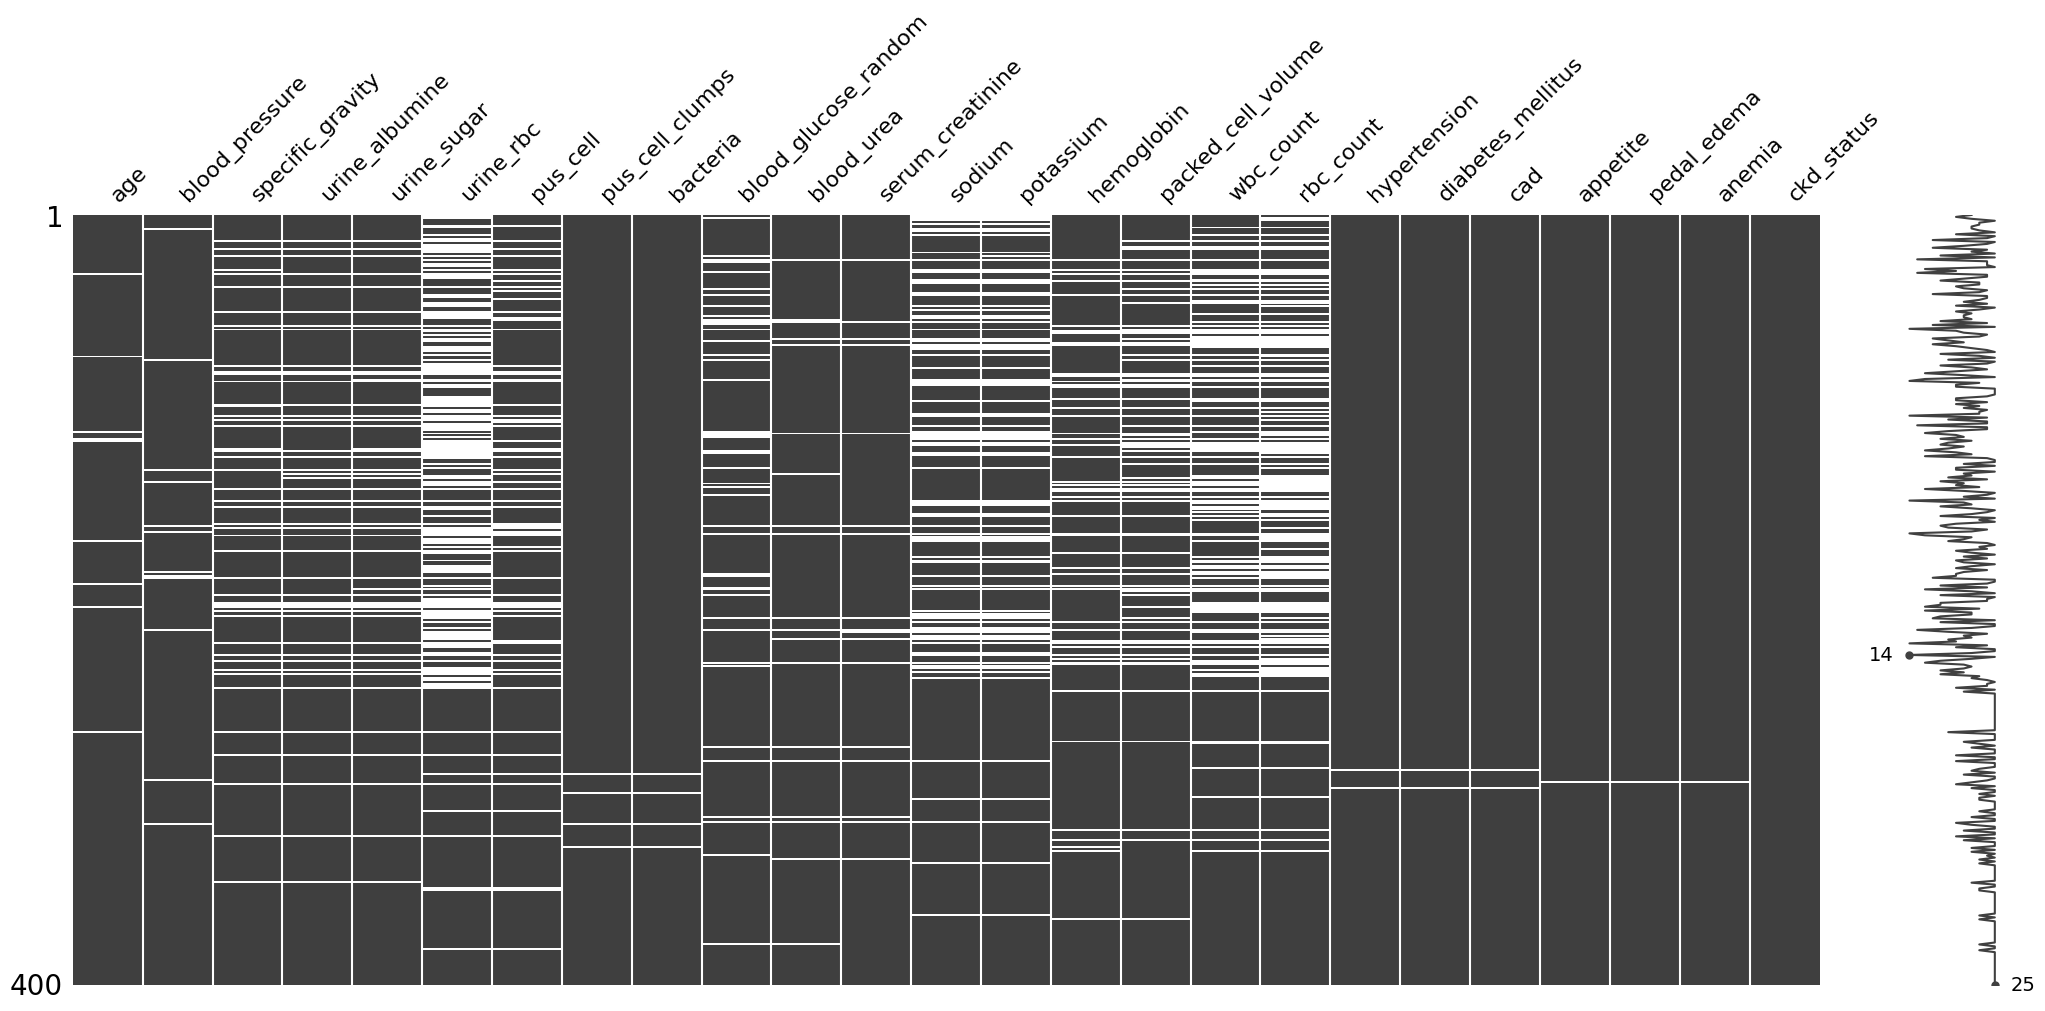

In [112]:
msno.matrix(df)
plt.show()

We computed the number of missing values for each variable and sorted them in descending order. 
We also visualized the spatial distribution of missing data using the missingno library.

The results shows that missingness is not uniformly distributed: urine_rbc, red blood cell count and white blood cell count exhibit the highest number of missing values; electrolyte measurements and anemia-related variables, such as hemoglobin and packed cell volume, also show non-negligible amount of missing data.

Conversely, demographic and clinical history variables are almost fully observed.

In [113]:
missing_table = (df.isnull().mean().sort_values(ascending=False).to_frame(name='missing_fraction'))

missing_table

,missing_fraction
urine_rbc,0.3800
rbc_count,0.3275
wbc_count,0.2650
potassium,0.2200
sodium,0.2175
packed_cell_volume,0.1775
pus_cell,0.1625
hemoglobin,0.1300
urine_sugar,0.1225
specific_gravity,0.1175


Above, the fraction of missing data for each variable, that can be visualized in the bar plot below. 

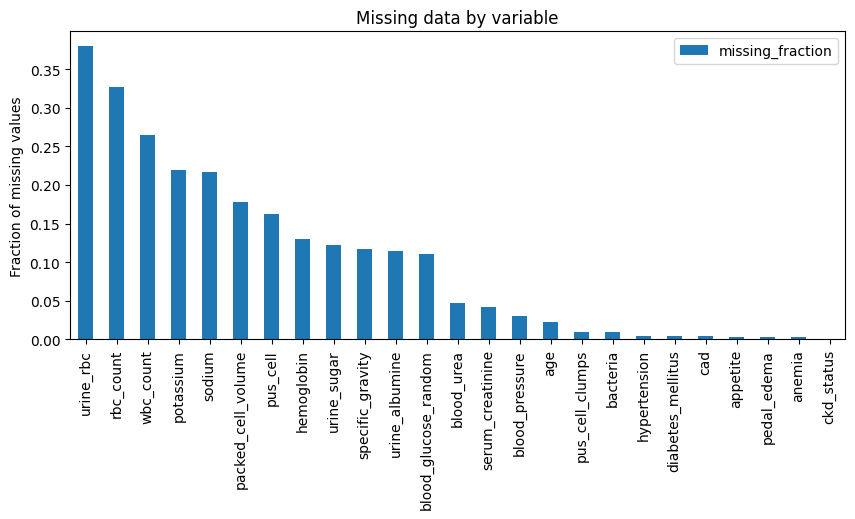

In [114]:
missing_table.plot(kind='bar', figsize=(10,4))
plt.ylabel('Fraction of missing values')
plt.title('Missing data by variable')
plt.show()

Since the maximum fraction of missing data is 0.38, there are no columns that contain too many missing values and that should be therefore entirely dropped (no column-wise deletion).

Also, given the relatively small sample size, case-wise deletion would represent a substantial loss of information. 

Therefore, missing values will be handled through appropriate imputation strategies within the preprocessing pipeline in a later section. 

## Class distribution

Let's now check whether classes are balanced and whether class imbalance handling may be needed.

In [115]:
df['ckd_status'].value_counts(normalize=True)

ckd_status
ckd       0.625
notckd    0.375
Name: proportion, dtype: float64

There are two classes with proportions summing to 1.
These two classes are moderately imbalanced with 63% of CKD observations and 37% of complementary non-CKD. This reflects the fact that the data of this dataset was collected from patients undergoing medical evaluation for kidney function and related conditions. 

Class imbalance will be taken into account during model evaluation with samplers, class-weighted models and the use of appropriate evaluation metrics.

## Descriptive Statistics of Numerical Features

The numerical features include demographic variables (age), physiological measurements (blood pressure), laboratory measurements from blood samples (serum creatinine, blood urea, elecrolytes, haemoglobin, blood glucose, packed cell volume, rbc and wbc counts) and urine analysis indicators (specific gravity, urine albumin, urine sugar).

### Global Descriptive Statistics

In [116]:
numeric_features = [
    'age', 'blood_pressure', 'specific_gravity', 'urine_albumine',
    'urine_sugar', 'blood_glucose_random', 'blood_urea', 
    'serum_creatinine', 'sodium', 'potassium', 'hemoglobin',
    'packed_cell_volume', 'rbc_count', 'wbc_count']

df[numeric_features].describe()

,age,blood_pressure,specific_gravity,urine_albumine,urine_sugar,blood_glucose_random,blood_urea,serum_creatinine,sodium,potassium,hemoglobin,packed_cell_volume,rbc_count,wbc_count
count,391.000000,388.000000,353.000000,354.000000,351.000000,356.000000,381.000000,383.000000,313.000000,312.000000,348.000000,329.000000,269.000000,294.000000
mean,51.483376,76.469072,1.017408,1.016949,0.450142,148.036517,57.425722,3.072454,137.528754,4.627244,12.526437,38.884498,4.707435,8406.122449
std,17.169714,13.683637,0.005717,1.352679,1.099191,79.281714,50.503006,5.741126,10.408752,3.193904,2.912587,8.990105,1.025323,2944.474190
min,2.000000,50.000000,1.005000,0.000000,0.000000,22.000000,1.500000,0.400000,4.500000,2.500000,3.100000,9.000000,2.100000,2200.000000
25%,42.000000,70.000000,1.010000,0.000000,0.000000,99.000000,27.000000,0.900000,135.000000,3.800000,10.300000,32.000000,3.900000,6500.000000
50%,55.000000,80.000000,1.020000,0.000000,0.000000,121.000000,42.000000,1.300000,138.000000,4.400000,12.650000,40.000000,4.800000,8000.000000
75%,64.500000,80.000000,1.020000,2.000000,0.000000,163.000000,66.000000,2.800000,142.000000,4.900000,15.000000,45.000000,5.400000,9800.000000
max,90.000000,180.000000,1.025000,5.000000,5.000000,490.000000,391.000000,76.000000,163.000000,47.000000,17.800000,54.000000,8.000000,26400.000000


### Distributional Plots

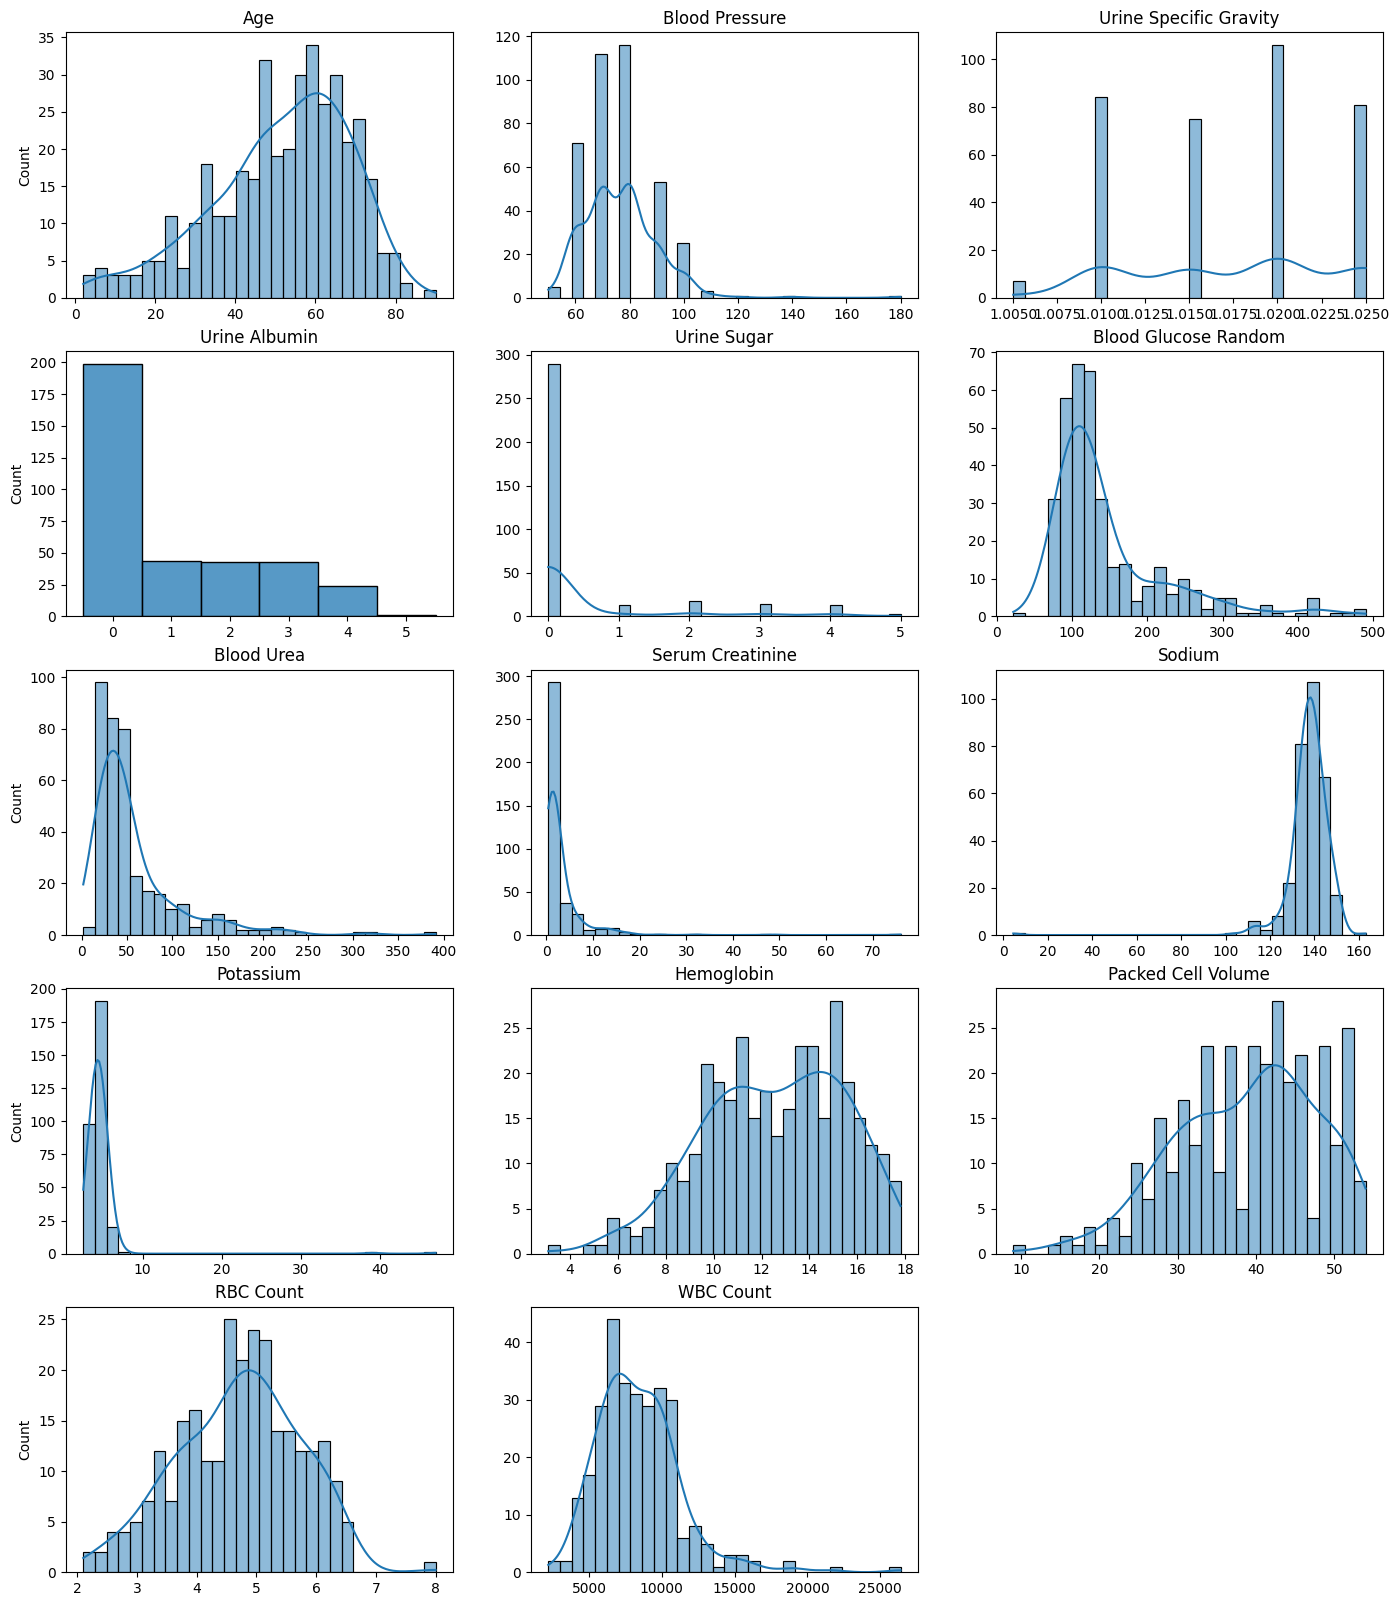

In [117]:
#Distributional plots: univariate distributions of numerical features
fig, axes = plt.subplots(5,3, figsize=(17,20))
axes = axes.flatten() 

num_var = [
    ('age', 'Age'),
    ('blood_pressure', 'Blood Pressure'),
    ('specific_gravity', 'Urine Specific Gravity'),
    ('urine_albumine', 'Urine Albumin'),
    ('urine_sugar', 'Urine Sugar'),
    ('blood_glucose_random', 'Blood Glucose Random'),
    ('blood_urea', 'Blood Urea'),
    ('serum_creatinine', 'Serum Creatinine'),
    ('sodium', 'Sodium'),
    ('potassium', 'Potassium'),
    ('hemoglobin', 'Hemoglobin'),
    ('packed_cell_volume', 'Packed Cell Volume'),
    ('rbc_count', 'RBC Count'),
    ('wbc_count', 'WBC Count')
]

for i, (var, title) in enumerate(num_var):
    if var == 'urine_albumine':
        sns.histplot(df[var], bins=6, discrete=True, ax=axes[i])
    else:
        sns.histplot(df[var], bins=30, kde=True, ax=axes[i])
    
    axes[i].set_title(title)
    axes[i].set_xlabel(None)

    if i in [0, 3, 6, 9,12]:
        axes[i].set_ylabel('Count')
    else:
        axes[i].set_ylabel(None)

for j in range(len(num_var), len(axes)):
    axes[j].axis('off')

plt.show()


The univariate distributions of numerical features reveal substantial heterogeneity across laboratory and physiological measurements. Variables related to renal function, such as serum creatinine, blood urea, and urine albumin, exhibit wide ranges and pronounced skewness. These patterns are clinically plausible and highlight the presence of laboratory measurements that directly capture renal dysfunction.

### Boxplots Stratified by CKD

Let's check whether numerical features differ systematically between CKD and non-CKD patients with boxplots stratified by CKD status.

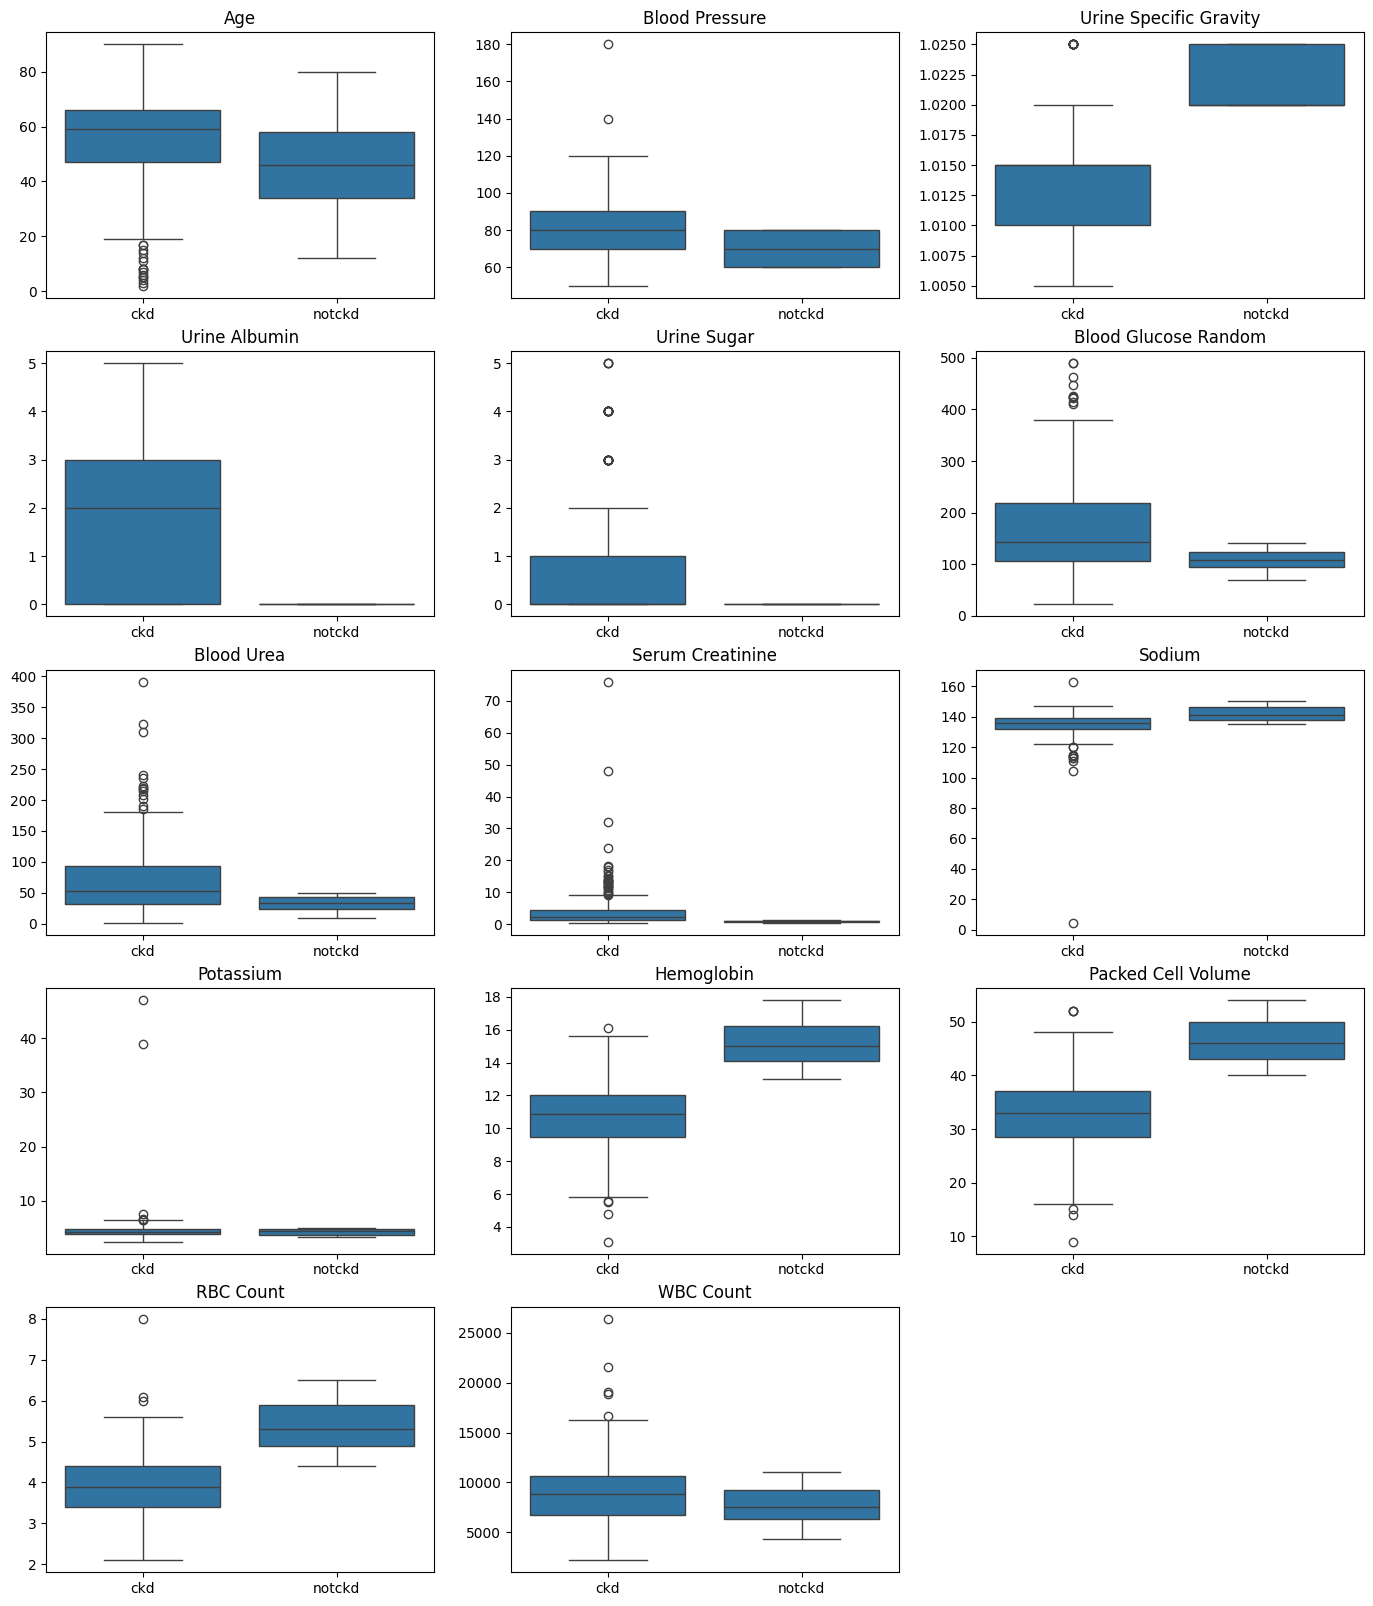

In [118]:
fig, axes = plt.subplots(5, 3, figsize=(17,20))
axes = axes.flatten()

for ax, (var, title) in zip(axes, num_var):
    sns.boxplot(
        x='ckd_status',
        y=var,
        data=df,
        ax=ax
    )
    ax.set_title(title)
    ax.set_xlabel(None)
    ax.set_ylabel(None)

for j in range(len(num_var), len(axes)):
    axes[j].axis('off')

plt.show()

We can observe marked differences between CKD and non-CKD patients for several laboratory variables. In particular, serum creatinine, blood urea, and urine albumin show near-complete separation between groups.

While this pronounced separation confirms the strong association between these variables and CKD status, it is also consistent with the fact that several of them function as direct diagnostic indicators rather than purely predictive variables, thus motivating the distinction between automated diagnostic reproduction and screening-oriented prediction in the following sections.

## Categorical Features Analysis

In [119]:
for var in categorical_features:
    print("\n", var)
    print(pd.crosstab(df[var], df["ckd_status"], normalize="columns"))



 urine_rbc
ckd_status       ckd  notckd
urine_rbc                   
abnormal    0.439252     0.0
normal      0.560748     1.0

 pus_cell
ckd_status       ckd  notckd
pus_cell                    
abnormal    0.391753     0.0
normal      0.608247     1.0

 pus_cell_clumps
ckd_status         ckd  notckd
pus_cell_clumps               
notpresent       0.832     1.0
present          0.168     0.0

 bacteria
ckd_status    ckd  notckd
bacteria                 
notpresent  0.912     1.0
present     0.088     0.0

 hypertension
ckd_status      ckd  notckd
hypertension               
no            0.412     1.0
yes           0.588     0.0

 diabetes_mellitus
ckd_status           ckd  notckd
diabetes_mellitus               
no                 0.452     1.0
yes                0.548     0.0

 cad
ckd_status    ckd  notckd
cad                      
no          0.864     1.0
yes         0.136     0.0

 appetite
ckd_status    ckd  notckd
appetite                 
good        0.672     1.0
poor      

Cross tabulation was used to examine the joint distribution of two variables (feature x ckd_status). The categorical analysis reveals significant differences in category distributions between CKD and non-CKD patients, indicating substantial discriminative potential of several categorical features.

## Data Correlation Analysis

Before proceeding to model development, correlation analysis is performed on numerical features to identify potential overlapping information among predictors (multicollinearity).

/tmp/ipykernel_112/482127462.py:12: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  corr_levels = corr.applymap(corr_strength)


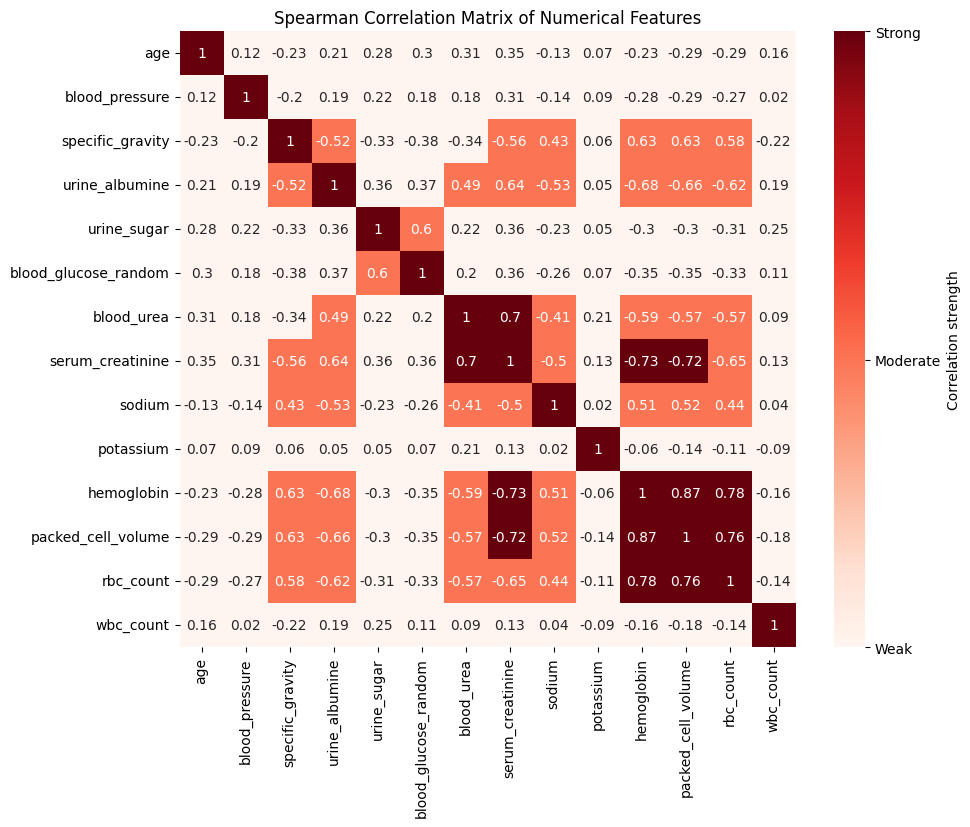

In [120]:
corr = df[numeric_features].corr(method='spearman') #spearman is better suited than default method Pearson because of non-normal distributions, heavy-skeweness and outliers

#defining three main correlation classes
def corr_strength(val):
    if abs(val) >= 0.7:
        return 0.9
    elif abs(val) >= 0.4:
        return 0.5
    else:
        return 0.15

corr_levels = corr.applymap(corr_strength)

#heatmap plotting
plt.figure(figsize=(10,8))
ax = sns.heatmap(corr_levels, annot=corr.round(2), cmap='Reds', square=True, cbar_kws={'label':'Correlation strength'})
plt.title('Spearman Correlation Matrix of Numerical Features')

cbar = ax.collections[0].colorbar
cbar.set_ticks([0.15, 0.5, 0.9])
cbar.set_ticklabels(['Weak', 'Moderate', 'Strong'])
plt.show()

The correlation matrix reveals localized strong associations among subsets of numerical features. In particular, serum creatinine and blood urea exhibit a strong positive correlation (0.7), indicating overlapping information related to renal function. Similarly, hemoglobin, packed cell volume and rbc count form a highly correlated group, consistent with the fact that all these three variables are anemia indicators.

This structure hightlights the presence of clusters of different variables that provide information about the same physiological mechanisms. As a result, correlation analysis provides additional motivation for the exclusion of redundant diagnostic features and dimensionality reduction in the screening-oriented modeling task.

## Automated Diagnostic Reproduction Using Full Clinical Data

## Data Preprocessing

Based on the exploratory data analysis, we move to the preprocessing step that ensures data quality and suitability for machine learning models. This step addresses missing values, categorical encoding, scaling, and class imbalance, and is designed to prevent data leakage.

### Encoding the Target Variable

Let's encode the target variable as a binary outcome, with CKD mapped to 1 and non-CKD mapped to 0.

In [121]:
df['ckd_status'] = df['ckd_status'].map({'ckd':1, 'notckd':0})

### Train and Test Sets

In [122]:
X = df.drop('ckd_status', axis=1)  #Features
y = df['ckd_status']  #Target variable

In [123]:
X.shape

(400, 24)

Now that X and y are defined, we split data in train and test sets.

In [124]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

Since the target variable is slightly imbalanced (63% of observations are labeled as CKD), stratified splitting is applied here to preserve class proportions.

### Preprocessing Pipeline

Looking at the distributional plots of numeric features in the previous section, it is clear that different features need different preprocessing strategies.

In particular, serum creatinine, blood urea and blood glucose are strongly right-skewed and have long tails. Since StandardScaler is sensitive to outliers and more suitable for symmetric data, in this case, it is preferrable to rescale data through RobustScaler that instead uses median and interquartile range thus maintaining the meaningfulness of extreme values.

Urine albumine and urine sugar are strongly right-skewed with many zero values that go from 0 to 5 and are not truly continuous. Urine specific gravity is a discrete set of predefined values contained in a very narrow range. Also for these cases, median and interquartile range are more representative and RobustScaler is to be preferred.

For the remaining numerical variables, which exhibit more symmetric distributions, it is safe to use StandardScaler.

To handle missing numerical values, SimpleImputer with median strategy is safe for skewed variables and remains conservative also for the more symmetric ones.

In [125]:
num_robust_var = [
    'serum_creatinine',
    'blood_urea', 
    'blood_glucose_random',
    'urine_albumine',
    'urine_sugar',
    'specific_gravity'
]

num_standard_var = [
    'age',
    'blood_pressure',
    'sodium',
    'potassium',
    'hemoglobin',
    'packed_cell_volume',
    'rbc_count',
    'wbc_count'
]

num_robust_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', RobustScaler())
])

num_standard_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

Analysing cross tabulations in the Categorical Feature Analysis section, we can see that all the categorical variables are binary and nominal (appetite's categories are semantic and could be interpreted as ordinal but will be treated nominally here), and therefore, their categories can be encoded in 1/0 through OneHotEncoder.


For missing categorical values, the safer thing to do is to use SimpleImputer with most_frequent strategy that keeps category proportions stable.

In [126]:
categorical_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(drop='first', handle_unknown='ignore'))
])

In [127]:
preprocessor = ColumnTransformer(
    transformers=[
        ('num_rob', num_robust_pipeline, num_robust_var),
        ('num_std', num_standard_pipeline, num_standard_var),
        ('cat', categorical_pipeline, categorical_features)
    ],
    remainder='drop'
)

We can visualize the effect of the scaling on the numeric variables of the dataset. 

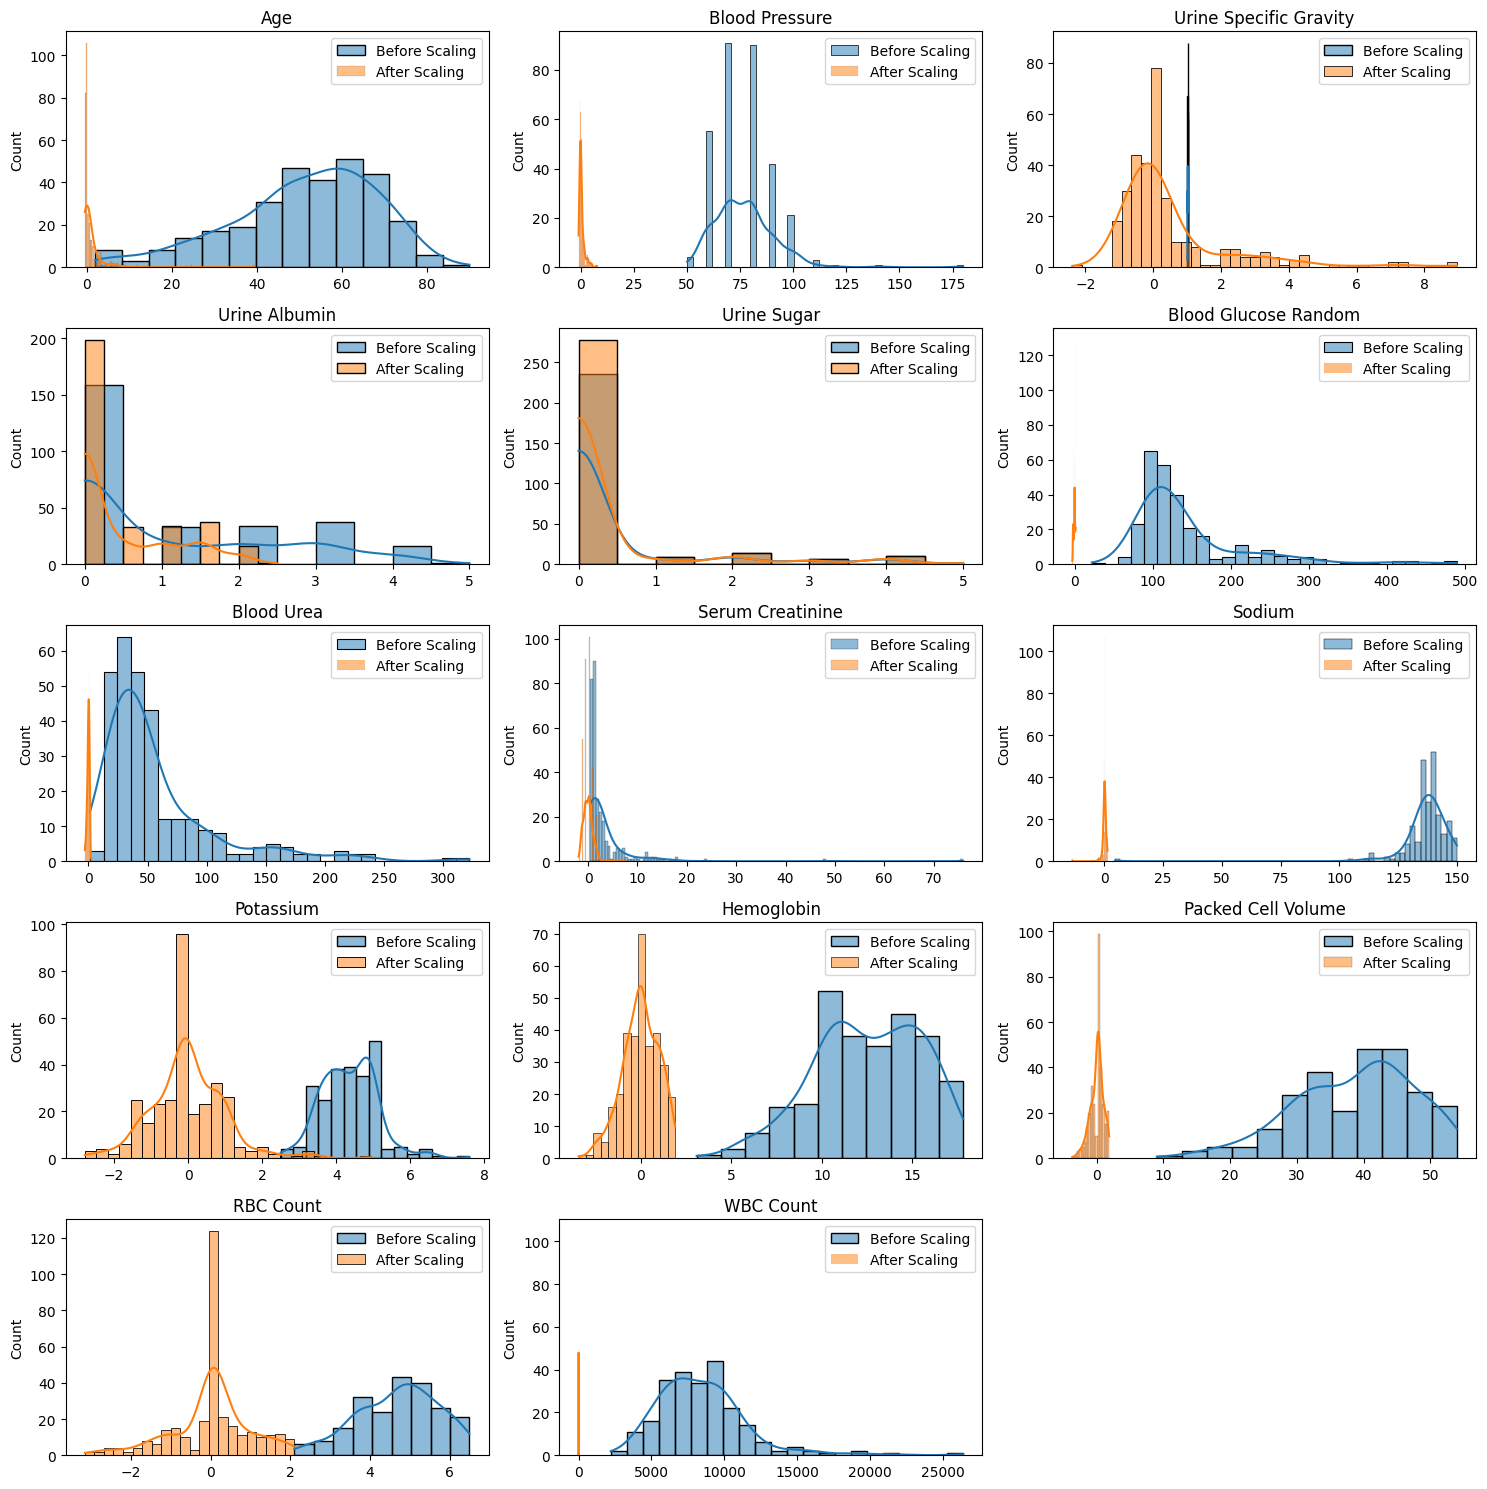

In [128]:
#Build a numeric only preprocessor
numeric_preprocessor = ColumnTransformer(
    transformers=[
        ('num_rob', num_robust_pipeline, num_robust_var),
        ('num_std', num_standard_pipeline, num_standard_var)
    ],
    remainder="drop"
)

#Fit on numeric train only, then transform numeric train
X_train_num_raw = X_train[numeric_features].copy()
X_train_num_scaled = numeric_preprocessor.fit_transform(X_train_num_raw)

#Convert transformed array back to DataFrame with meaningful column names
scaled_feature_names = numeric_features
X_train_num_scaled = pd.DataFrame(X_train_num_scaled, columns=scaled_feature_names, index=X_train.index)

#Plot before vs after (two plots per feature)
fig, axes = plt.subplots(5, 3, figsize=(15, 15))
axes = axes.flatten()



for ax, (var, title) in zip(axes, num_var):
    sns.histplot(X_train_num_raw[var].dropna(), ax=ax, kde=True, label='Before Scaling')
    sns.histplot(X_train_num_scaled[var].dropna(), ax=ax, kde=True, label='After Scaling')
    ax.set_title(title)
    ax.set_xlabel(None)
    ax.legend()

# Hide unused subplots
for j in range(i + 1, len(axes)):
    axes[j].axis("off")

plt.tight_layout()
plt.show()

### Model training

We can now define a model pipeline for the diagnostic classification task.

In [129]:
model_pipeline = IMBPipeline([
    ('trans', preprocessor),
    ('dim_reduction', PCA(n_components=0.85)),
    ('classifier', LogisticRegression(penalty="l1", solver="liblinear", class_weight="balanced")) #used l1 instead of PCA and class_weight="balanced" to deal with class imbalance 
])

model_pipeline.fit(X_train, y_train)

Pipeline(steps=[('trans',
                 ColumnTransformer(transformers=[('num_rob',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   RobustScaler())]),
                                                  ['serum_creatinine',
                                                   'blood_urea',
                                                   'blood_glucose_random',
                                                   'urine_albumine',
                                                   'urine_sugar',
                                                   'specific_gravity']),
                                                 ('num_std',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   Sta...
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder(drop='first',
                                                                                 handle_unknown='ignore'))]),
                                                  ['urine_rbc', 'pus_cell',
                                                   'pus_cell_clumps',
                                                   'bacteria', 'hypertension',
                                                   'diabetes_mellitus', 'cad',
                                                   'appetite', 'pedal_edema',
                                                   'anemia'])])),
                ('dim_reduction', PCA(n_components=0.85)),
                ('classifier',
                 LogisticRegression(class_weight='balanced', penalty='l1',
                                    solver='liblinear'))])

### Model performance evaluation

To evaluate model performance in a binary diagnostic task, clinically relevant evaluation metrics are used, such as sensitivity (recall), specificity and F1 score which balances precision and recall.

In [130]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

specificity_scorer = make_scorer(recall_score,pos_label=0)

scoring = {
    'Sensitivity': 'recall',
    'Specificity': specificity_scorer,
    'F1': 'f1'
}

cv_results = cross_validate(
    model_pipeline,
    X_train, y_train,
    cv=cv,
    scoring=scoring,
    return_train_score=True
)

rows = []
for m in scoring:
    rows.append({
        'Metric': m,
        'Train (CV mean)': cv_results[f"train_{m}"].mean(),
        'Test (CV mean)':  cv_results[f"test_{m}"].mean()
    })

results_df = pd.DataFrame(rows)
results_df

,Metric,Train (CV mean),Test (CV mean)
0,Sensitivity,0.976250,0.970000
1,Specificity,0.995833,0.991667
2,F1,0.986735,0.982214


In [131]:
y_pred_aut = model_pipeline.predict(X_test)
f1_aut = f1_score(y_test, y_pred_aut)
print(f"F1 score: {f1_aut:.3f}")

F1 score: 0.980


This table compares model performances on training and validation CV sets: the scores are consistently high across all metrics with test sensitivity of 97%, indicating that most CKD cases are correctly identified, and specificity close to 100%, meaning that almost no false positive cases were observed across folds. The almost null difference between training and validation scores suggests limited overfitting and stable generalization.

The final evaluation score on the previously left out test set confirms that, when full diagnostic information is available, the model is able to accurately distinguish between CKD and non-CKD cases, confirming the quasi-deterministic nature of the task and the feasability of an automated diagnostic support to the clinical diagnosis.

In many real-world scenario, however, the goal is not confirmatory diagnosis but early-stage screening where only limited and non-diagnostic information may be available. To assess the applicability of a screening-like classification task, in the next section diagnostic variables will be excluded from the set of predictive features, so that the model must rely on weaker signals to identify individuals at potential risk of CKD.


## Screening\-Oriented CKD Prediction without Diagnostic Variables

### Detection of Direct Diagnostic Indicators

In the correlation matrix above, several variables forming highly correlated clusters correspond to established diagnostic markers of CKD, in particular numerical urine analysis results and other categorical renal function indicators. While these variables enable near-perfect diagnostic performance, they are typically obtained after clinical suspicion arises. To simulate a screening scenario, these variables are excluded in the next section.

In [132]:
diagnostic_variables = [
    'urine_albumine',
    'specific_gravity',
    'pus_cell_clumps',
    'urine_sugar',
    'urine_rbc', 
    'pus_cell', 
    'bacteria'
]

We define a new predictive set (X_sc), that comprehends only routinary laboratory measurements.

In [133]:
X_sc = X.drop(columns=diagnostic_variables)
y_sc = y

X_sc.shape

(400, 17)

In [134]:
y_sc.shape

(400,)

In [135]:
X_sc

,age,blood_pressure,blood_glucose_random,blood_urea,serum_creatinine,sodium,potassium,hemoglobin,packed_cell_volume,wbc_count,rbc_count,hypertension,diabetes_mellitus,cad,appetite,pedal_edema,anemia
0,48.0,80.0,121.0,36.0,1.2,NaN,NaN,15.4,44.0,7800.0,5.2,yes,yes,no,good,no,no
1,7.0,50.0,NaN,18.0,0.8,NaN,NaN,11.3,38.0,6000.0,NaN,no,no,no,good,no,no
2,62.0,80.0,423.0,53.0,1.8,NaN,NaN,9.6,31.0,7500.0,NaN,no,yes,no,poor,no,yes
3,48.0,70.0,117.0,56.0,3.8,111.0,2.5,11.2,32.0,6700.0,3.9,yes,no,no,poor,yes,yes
4,51.0,80.0,106.0,26.0,1.4,NaN,NaN,11.6,35.0,7300.0,4.6,no,no,no,good,no,no
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
395,55.0,80.0,140.0,49.0,0.5,150.0,4.9,15.7,47.0,6700.0,4.9,no,no,no,good,no,no
396,42.0,70.0,75.0,31.0,1.2,141.0,3.5,16.5,54.0,7800.0,6.2,no,no,no,good,no,no
397,12.0,80.0,100.0,26.0,0.6,137.0,4.4,15.8,49.0,6600.0,5.4,no,no,no,good,no,no
398,17.0,60.0,114.0,50.0,1.0,135.0,4.9,14.2,51.0,7200.0,5.9,no,no,no,good,no,no


### Correlation Analysis

Correlation analysis is here performed again to identify potential multicollinearity among the remaining predictors.

In [136]:
#Defyning the list of numerical features to be used in the screening-like modeling task

numeric_features_sc = [
    'age', 'blood_pressure', 'blood_glucose_random', 'packed_cell_volume', 
    'sodium', 'potassium', 'wbc_count', 'rbc_count', 'hemoglobin', 'serum_creatinine',
    'blood_urea']


/tmp/ipykernel_112/281765519.py:12: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  corr_levels = corr.applymap(corr_strength)


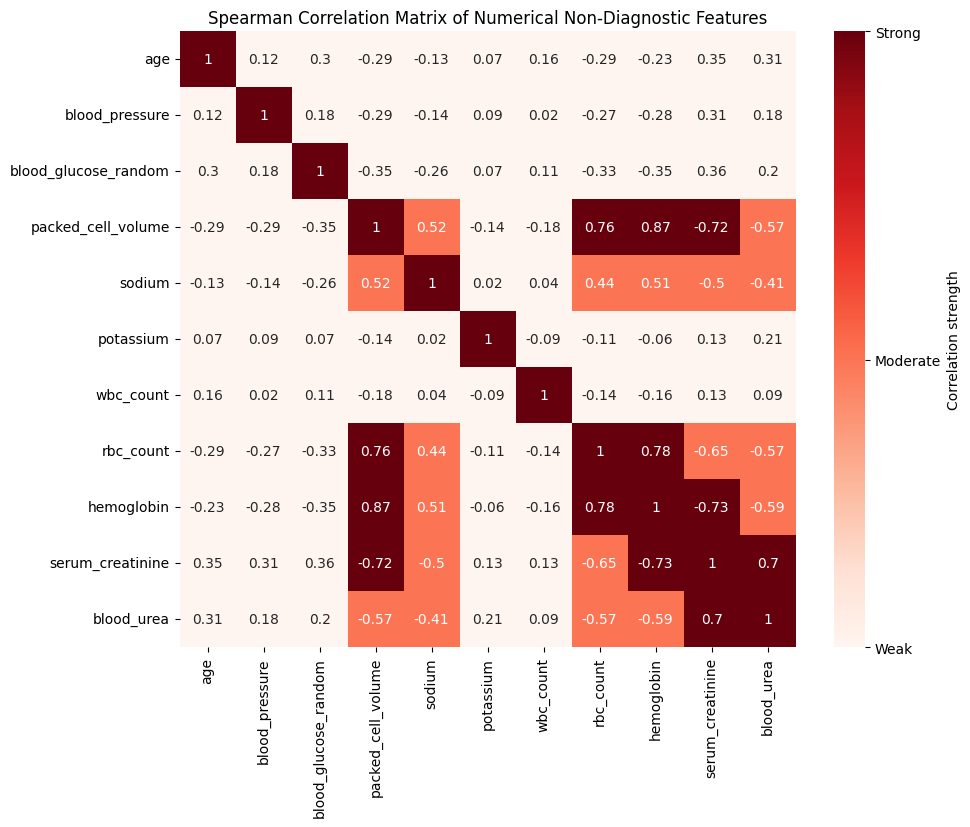

In [137]:
corr = X_sc[numeric_features_sc].corr(method='spearman') 

#defining three main correlation classes
def corr_strength(val):
    if abs(val) >= 0.7:
        return 0.9
    elif abs(val) >= 0.4:
        return 0.5
    else:
        return 0.15

corr_levels = corr.applymap(corr_strength)

#heatmap plotting
plt.figure(figsize=(10,8))
ax = sns.heatmap(corr_levels, annot=corr.round(2), cmap='Reds', square=True, cbar_kws={'label':'Correlation strength'})
plt.title('Spearman Correlation Matrix of Numerical Non-Diagnostic Features')

cbar = ax.collections[0].colorbar
cbar.set_ticks([0.15, 0.5, 0.9])
cbar.set_ticklabels(['Weak', 'Moderate', 'Strong'])
plt.show()

As expected, the result shows strong correlation between hemoglobin, red blood cell count and packed_cell_volume, which are related to anemia (a common comorbidity in CKD patient), plus other clusters of multicollinearity that may affect model stability. To adress this problem, in the next section, dimensionality reduction techniques will be used to mitigate redundancy. 

## Data Preprocessing

### Preprocessing Pipeline

The preprocessing strategy remains unchanged. However, the pipeline is rebuilt and will be refitted using updated lists of numerical and categorical features. This ensures that all the preprocessing steps are correctly adapted to the new reduced set of predictors and prevents information leakage. 

In [138]:
num_robust_var_sc = [
    'blood_glucose_random',
    'serum_creatinine',
    'blood_urea'
]

num_standard_var_sc = [
    'age',
    'blood_pressure',
    'sodium',
    'potassium',
    'wbc_count',
    'rbc_count',
    'hemoglobin',
    'packed_cell_volume'
]

categorical_features_sc = [
    'hypertension', 'diabetes_mellitus', 'cad', 'appetite', 
    'pedal_edema', 'anemia']

In [139]:
preprocessor_sc = ColumnTransformer(
    transformers=[
        ('num_rob', num_robust_pipeline, num_robust_var_sc),
        ('num_std', num_standard_pipeline, num_standard_var_sc),
        ('cat', categorical_pipeline, categorical_features_sc)
    ],
    remainder='drop'
)

### Train and Test Sets

Before the model selection step, we split X_sc and y_sc in train and test sets.

In [140]:
X_sc_train, X_sc_test, y_sc_train, y_sc_test = train_test_split(X_sc, y_sc, test_size=0.2, stratify=y_sc, random_state=42)

## Model Selection

The objective of this section is to find a predictive model that generalizes well to unseen data. To this end, we first define a starting model pipeline. Then, model comparison and hyperparameter tuning are performed using nested cross-validation to prevent information leakege. And finally, the best performing model will be refined and evaluated on a held-out test set.

We start with defining the starting model pipeline.

In [141]:
starting_pipeline = IMBPipeline([
    ('trans', preprocessor_sc),
    ('sampler', 'passthrough'),
    ('dim_reduction', 'passthrough'),
    ('classifier', LogisticRegression())
])

Fit the starting pipeline to the training set and calculate the initial permormance metrics.

In [142]:
starting_pipeline.fit(X_sc_train, y_sc_train)

Pipeline(steps=[('trans',
                 ColumnTransformer(transformers=[('num_rob',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   RobustScaler())]),
                                                  ['blood_glucose_random',
                                                   'serum_creatinine',
                                                   'blood_urea']),
                                                 ('num_std',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['age', 'blood_pressure',
                                                   'sodium',...
                                                   'hemoglobin',
                                                   'packed_cell_volume']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder(drop='first',
                                                                                 handle_unknown='ignore'))]),
                                                  ['hypertension',
                                                   'diabetes_mellitus', 'cad',
                                                   'appetite', 'pedal_edema',
                                                   'anemia'])])),
                ('sampler', 'passthrough'), ('dim_reduction', 'passthrough'),
                ('classifier', LogisticRegression())])

In [143]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

specificity_scorer = make_scorer(recall_score,pos_label=0)

scoring = {
    'Initial sensitivity score': 'recall',
    'Initial specificity score': specificity_scorer,
    'Initial F1 score': 'f1'
}

cv_results = cross_validate(
    starting_pipeline,
    X_sc_train, y_sc_train,
    cv=cv,
    scoring=scoring,
    return_train_score=True
)

rows = []
for m in scoring:
    rows.append({
        'Metric': m,
        'Train (CV mean)': cv_results[f"train_{m}"].mean(),
        'Validation (CV mean)':  cv_results[f"test_{m}"].mean()
    })

results_df_sc = pd.DataFrame(rows)
results_df_sc

,Metric,Train (CV mean),Validation (CV mean)
0,Initial sensitivity score,0.995000,0.975000
1,Initial specificity score,0.975000,0.958333
2,Initial F1 score,0.990062,0.975156


These high scores, reflect the use of a highly flexible model with limited regularization.

The aim of the following sections is to improve and assess generalization. 

## Hyperparameter Tuning

First, we have to find the best hyperparameter combination. To this end, we start with defining different dictionaries: one for sampling, one for dimensionality reduction and one for the classifier, then, through cross-validation we will evaluate which combination exhibits the best performance.

In [174]:
sampler_configs = [
    {
        'sampler': [None]  #The element is bypassed
    },
    {
        'sampler':[RandomOverSampler(random_state=42)],
        'sampler__sampling_strategy':['minority', 0.9, 0.75]
    }
]

dim_reduction_configs = [
    {
        'dim_reduction': [PCA()],
        'dim_reduction__n_components': [0.7, 0.80, 0.85, 0.9]
    },
    {
        'dim_reduction': [LDA()],
        'dim_reduction__n_components': [1]
    },
]

classifier_configs = [
    {
        'classifier': [Perceptron()],
        'classifier__eta0' : loguniform(1e-4, 1e-2),
        'classifier__max_iter': [50, 100, 300],
        'classifier__class_weight' : [None, 'balanced']
    },
    {
        'classifier': [LogisticRegression(max_iter=5000)],
        'classifier__C' : loguniform(0.001,100),
        'classifier__penalty': ['l1'],
        'classifier__solver': ['saga', 'liblinear'],
        'classifier__class_weight' : [None, 'balanced']
    },
    {
        'classifier': [LogisticRegression(max_iter=5000)],
        'classifier__C': loguniform(0.001,100),
        'classifier__penalty': ['l2'],
        'classifier__solver': ['lbfgs', 'liblinear', 'saga'],
        'classifier__class_weight' : [None, 'balanced']
    },
    {
        'classifier': [RandomForestClassifier(random_state=42, n_jobs=-1)],
        'classifier__n_estimators': randint(100, 400),
        'classifier__max_depth': [3, 5, 8, 12],
        'classifier__min_samples_split': randint(5, 30),
        'classifier__min_samples_leaf': randint(5, 30),
        'classifier__max_features': ['sqrt', 'log2'],
        'classifier__bootstrap': [True],
        'classifier__class_weight': [None, 'balanced']
    }
]

Because of the precence of categorical variables on which we used One Hot Encoder, SMOTE was excluded to avoid the generation of synthetic samples which, for categorical features, would have led to fractional categories, which are not miningful and increase the risk of overoptimistic CV scores.

Given the presence of strongly correlated physiological measurements and the limited sample size of our dataset, dimensionality reduction was forced to mitigate multicollinearity and stabilize the model.

Moreover, due to the small sample size combined with oversampling, KNN which is a distance-based method was excluded to avoid high variance and to improve stability of the model.

Next, the Carthesian product is used to generate all possible combinations.

In [177]:
pipeline_configs = [dict(itertools.chain(*(e.items() 
for e in configuration))) 
for configuration in 
itertools.product(sampler_configs,dim_reduction_configs,classifier_configs)]

print(f'Number of all possible configurations: {len(pipeline_configs)}')

Number of all possible configurations: 16


With nested-cross validation we identify 5 different best candidates to be our reference model. The RandomizedSearchCV object will implement the inner loop of the nested CV, while the outer loop will be implemented by cross_validate that performs cross-validation.


In [180]:
inner_cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
outer_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

random_search = RandomizedSearchCV(starting_pipeline,
    param_distributions=pipeline_configs,
    n_iter=len(pipeline_configs) * 5,
    n_jobs=-1,
    cv = inner_cv,
    scoring='f1',
    random_state=42
)

In [183]:
scores = cross_validate(
    random_search, 
    X_sc_train, 
    y_sc_train, 
    scoring='f1', 
    cv = outer_cv, 
    return_estimator=True, 
    verbose=3,
    n_jobs=-1)

[Parallel(n_jobs=-1)]: Using backend LokyBackend with 2 concurrent workers.
[CV] END ......................................., score=0.949 total time=  35.9s
[CV] END ......................................., score=0.987 total time=  36.3s
[CV] END ......................................., score=0.930 total time=  35.4s
[CV] END ......................................., score=0.987 total time=  35.2s
[CV] END ......................................., score=0.987 total time=  32.6s
[Parallel(n_jobs=-1)]: Done   5 out of   5 | elapsed:  1.8min finished


In [201]:
for index, estimator in enumerate(scores['estimator']):
    print(f"Estimator number {index+1}:")
    print(estimator.best_estimator_.get_params()['sampler'])
    print(estimator.best_estimator_.get_params()['dim_reduction'])
    print(estimator.best_estimator_.get_params()['classifier'],estimator.best_estimator_.get_params()['classifier'].get_params())
    print(scores['test_score'][index])
    print('-'*10)

Estimator number 1:
RandomOverSampler(random_state=42, sampling_strategy=0.75)
PCA(n_components=0.85)
RandomForestClassifier(max_depth=8, min_samples_leaf=6, min_samples_split=6,
                       n_estimators=387, n_jobs=-1, random_state=42) {'bootstrap': True, 'ccp_alpha': 0.0, 'class_weight': None, 'criterion': 'gini', 'max_depth': 8, 'max_features': 'sqrt', 'max_leaf_nodes': None, 'max_samples': None, 'min_impurity_decrease': 0.0, 'min_samples_leaf': 6, 'min_samples_split': 6, 'min_weight_fraction_leaf': 0.0, 'n_estimators': 387, 'n_jobs': -1, 'oob_score': False, 'random_state': 42, 'verbose': 0, 'warm_start': False}
0.9873417721518987
----------
Estimator number 2:
None
PCA(n_components=0.9)
LogisticRegression(C=1.81888942304678, max_iter=5000) {'C': 1.81888942304678, 'class_weight': None, 'dual': False, 'fit_intercept': True, 'intercept_scaling': 1, 'l1_ratio': None, 'max_iter': 5000, 'multi_class': 'auto', 'n_jobs': None, 'penalty': 'l2', 'random_state': None, 'solver': 'lb

To select one of these five candidate models, we re-train each of them with the entire sceening training set and compare their performances on both the train and the test set.

In [189]:
f1_test_scores = []
for estimator in scores['estimator']:
    estimator.best_estimator_.fit(X_sc_train, y_sc_train)
    y_pred_train_sc = estimator.best_estimator_.predict(X_sc_train)
    y_pred_test_sc = estimator.best_estimator_.predict(X_sc_test)
    f1_train_sc = f1_score(y_sc_train, y_pred_train_sc)
    f1_test_sc = f1_score(y_sc_test, y_pred_test_sc)
    f1_test_scores.append(f1_test_sc)
    print(f'F1 on training set:{f1_train_sc}, F1 on test set:{f1_test_sc}')

F1 on training set:0.9770992366412213, F1 on test set:0.9484536082474226
F1 on training set:0.975, F1 on test set:0.9375
F1 on training set:0.9417989417989417, F1 on test set:0.888888888888889
F1 on training set:0.9696969696969697, F1 on test set:0.9484536082474226
F1 on training set:0.9417989417989417, F1 on test set:0.888888888888889


Model performance is stable across folds. Training scores remain higher than test scores and the observed gaps are moderate and consistent with expected variance in small datasets, indicating no severe overfitting.

/tmp/ipykernel_112/1733644232.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x='Candidate', y='F1 Score', data=results_bar, palette="coolwarm")


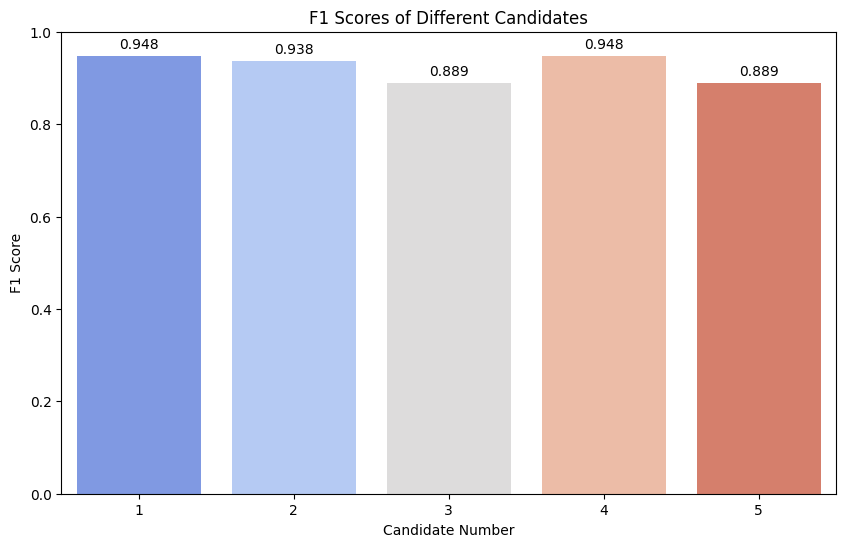

In [192]:
results_bar = pd.DataFrame({
    'Candidate': np.arange(1, len(scores['test_score']) + 1),
    'F1 Score': f1_test_scores
})

# Bar Chart for Candidate Performance
plt.figure(figsize=(10, 6))
ax = sns.barplot(x='Candidate', y='F1 Score', data=results_bar, palette="coolwarm")

for p in ax.patches:
    ax.annotate(
        f"{p.get_height():.3f}",
        (p.get_x() + p.get_width() / 2., p.get_height()),
        ha='center',
        va='bottom',
        fontsize=10,
        xytext=(0, 3),
        textcoords='offset points'
    )

plt.title("F1 Scores of Different Candidates")
plt.xlabel("Candidate Number")
plt.ylabel("F1 Score")
plt.ylim(0, 1)  # Ensuring scores are within valid range
plt.show()

Estimators 1 and 4 identically performed despite having very different structures (Random Forest vs Logistic Regression) so there is no consistent performance gain from the non-linear model, suggesting that the dominant relationships in the data are approximately linear. For this reasons, and also in accordance with the principle of parsimony (Occam’s razor principle) for which given equal results a simpler model is to be preferred, we will consider estimator 4 (Logistic Regression) as our best candidate.


## Refinement of the Selected Model

Based on estimator 4, the final model should include RandomOverSampler, PCA and LogisticRegression. 

In this final step, we re-run hyperparameter optimization slightly varying the ranges of the parameters for Principal Component Analysis and Logistic Regression.

None
PCA(n_components=0.9)
LogisticRegression(C=0.1135494582684592, max_iter=5000, penalty='l1',
                   solver='saga') {'C': 0.1135494582684592, 'class_weight': None, 'dual': False, 'fit_intercept': True, 'intercept_scaling': 1, 'l1_ratio': None, 'max_iter': 5000, 'multi_class': 'auto', 'n_jobs': None, 'penalty': 'l1', 'random_state': None, 'solver': 'saga', 'tol': 0.0001, 'verbose': 0, 'warm_start': False}
0.9873417721518987

In [204]:
selected_pipeline = IMBPipeline([
    ('trans', preprocessor_sc),
    #('sample', RandomOverSampler(random_state=42, sampling_strategy=0.75)),
    ('dim_reduction', PCA()),
    ('classifier',LogisticRegression(max_iter=5000, solver='saga', penalty = 'l1', class_weight=None))
])

In [207]:
params = {
    'dim_reduction__n_components': [0.85, 0.9, 0.95],
    'classifier__C': loguniform(1e-2, 10) 
}

In [210]:
cv_folds = RepeatedStratifiedKFold(n_splits=5, n_repeats=1)

rs_best = RandomizedSearchCV(
    estimator = selected_pipeline,
    param_distributions = params,
    cv = cv_folds,
    n_iter=20,
    scoring='f1',
    random_state=42,
    n_jobs=-1
)

In [216]:
rs_best.fit(X_sc_train, y_sc_train)

RandomizedSearchCV(cv=RepeatedStratifiedKFold(n_repeats=1, n_splits=5, random_state=None),
                   estimator=Pipeline(steps=[('trans',
                                              ColumnTransformer(transformers=[('num_rob',
                                                                               Pipeline(steps=[('imputer',
                                                                                                SimpleImputer(strategy='median')),
                                                                                               ('scaler',
                                                                                                RobustScaler())]),
                                                                               ['blood_glucose_random',
                                                                                'serum_creatinine',
                                                                                'blood_urea']),
                                                                              ('num_std',
                                                                               Pipeline(steps=[('imputer'...
                                                                                'appetite',
                                                                                'pedal_edema',
                                                                                'anemia'])])),
                                             ('dim_reduction', PCA()),
                                             ('classifier',
                                              LogisticRegression(max_iter=5000,
                                                                 penalty='l1',
                                                                 solver='saga'))]),
                   n_iter=20, n_jobs=-1,
                   param_distributions={'classifier__C': <scipy.stats._distn_infrastructure.rv_continuous_frozen object at 0x7f4a2e6a8ed0>,
                                        'dim_reduction__n_components': [0.85,
                                                                        0.9,
                                                                        0.95]},
                   random_state=42, scoring='f1')

In [219]:
rs_best.best_params_

{'classifier__C': 0.2386418878005606, 'dim_reduction__n_components': 0.85}

In [222]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

specificity_scorer = make_scorer(recall_score,pos_label=0)

scoring = {
    'Final sensitivity score': 'recall',
    'Final specificity score': specificity_scorer,
    'Final F1 score': 'f1'
}

cv_results = cross_validate(
    rs_best.best_estimator_,
    X_sc_train, y_sc_train,
    cv=cv,
    scoring=scoring,
    return_train_score=True
)

rows = []
for m in scoring:
    rows.append({
        'Metric': m,
        'Train (CV mean)': cv_results[f"train_{m}"].mean(),
        'Validation (CV mean)':  cv_results[f"test_{m}"].mean()
    })

results_df_sc = pd.DataFrame(rows)
results_df_sc

,Metric,Train (CV mean),Validation (CV mean)
0,Final sensitivity score,0.962500,0.960000
1,Final specificity score,0.956250,0.950000
2,Final F1 score,0.967942,0.964927


Performance of the final model on the held out test set y_sc:

In [225]:
y_pred_sc_fin = rs_best.best_estimator_.predict(X_sc_test)

sensitivity_sc = recall_score(y_sc_test, y_pred_sc_fin)
print(f"Sensitivity score on test set: {sensitivity_sc:.3f}")

specificity_sc = recall_score(y_sc_test, y_pred_sc_fin, pos_label=0)
print(f"Specificity score on test set: {specificity_sc:.3f}")

f1_sc = f1_score(y_sc_test, y_pred_sc_fin)
print(f"F1 score on test set: {f1_sc:.3f}")

Sensitivity score on test set: 0.920
Specificity score on test set: 0.967
F1 score on test set: 0.948


Comparing the above CV results with the ones obtained at the very beginning of the Model Selection phase on the starting_pipeline, we see how scores slighlty lowered. This reduction is expected and reflects the use of stronger regularization and dimensionality reduction to reduce model variance and mitigate overfitting in a small sample-size setting. Importantly, the tuned refined model shows stable and competitive performance on the held-out test set, with a high F1 score consistent with the F1 CV score.

## Bias\-Variance Trade\-off Analysis

In this section, we use the learning curve to analyse the behaviour of the model as the size of the training set increases, and the validation curve to examine how the model performance varies as a function of the Logistic Regression regularization parameter C. 

This analysis allows us to assess whether the final model suffers from underfitting or overfitting and to evaluate its generalization capability. 

### Learning Curve

In [228]:
cls = rs_best.best_estimator_

In [231]:
train_sizes, train_scores, test_scores = learning_curve(cls,
                                                       X=X_sc_train,
                                                       y=y_sc_train,
                                                       train_sizes= np.linspace(0.2, 1.0, 9),
                                                       cv = 5,
                                                       n_jobs = -1,
                                                       scoring = 'f1',
                                                       shuffle = True,
                                                       random_state=42)

(0.85, 1.015)

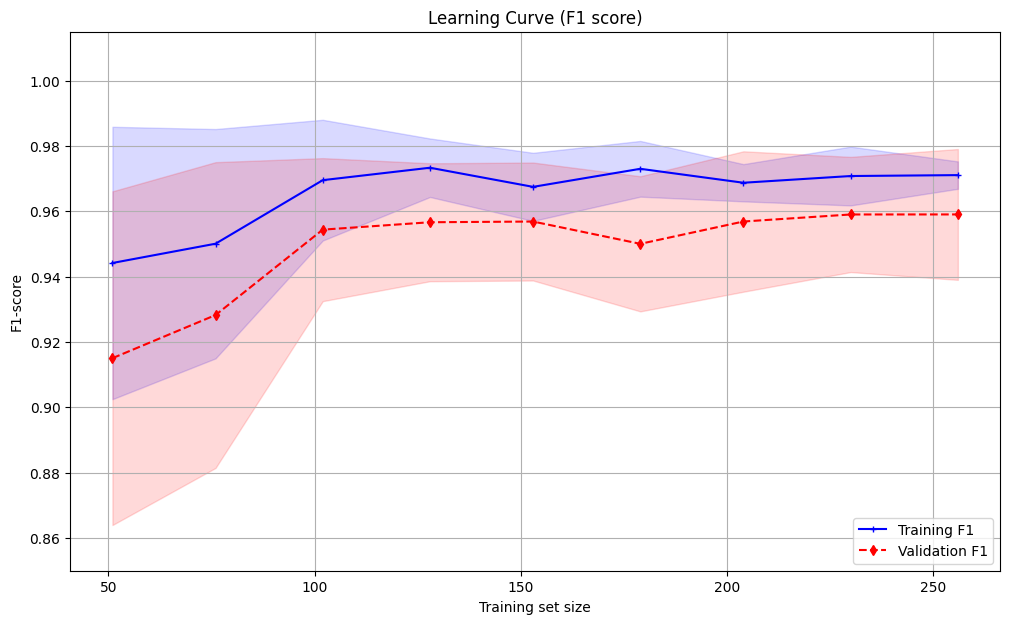

In [234]:
train_mean = np.mean(train_scores, axis=1) #for each train_size we compute the mean of the train F1 score across the 5 folds
train_std = np.std(train_scores, axis=1)
test_mean = np.mean(test_scores, axis=1)
test_std = np.std(test_scores, axis=1)

fig=plt.figure(figsize=(12,7))
ax = fig.add_subplot()

ax.plot(train_sizes, train_mean,
         color='blue', marker='+',
         markersize=5, label='Training F1')

ax.fill_between(train_sizes,
                 train_mean + train_std,
                 train_mean - train_std,
                 alpha=0.15, color='blue')

ax.plot(train_sizes, test_mean,
         color='red', linestyle='--',
         marker='d', markersize=5,
         label='Validation F1')

ax.fill_between(train_sizes,
                 test_mean + test_std,
                 test_mean - test_std,
                 alpha=0.15, color='red')

ax.grid()
ax.set_title("Learning Curve (F1 score)")
ax.set_xlabel('Training set size')
ax.set_ylabel('F1-score')
ax.legend(loc='lower right')
ax.set_ylim([0.85, 1.015])

Due to the relatively small sample size, the learning curve is computed over a limited range of training sizes and exhibits some variability across folds. Overall, the small gap between training and validation F1-scores suggests good generalization and no evident overfitting.

### Validation Curve

In [237]:
range_C = [0.0001, 0.001,0.01,0.1,1,10,100]
train_scores, test_scores = validation_curve(cls,
        X=X_sc_train, 
        y=y_sc_train, 
        param_range=range_C, 
        param_name='classifier__C',
        cv=5, 
        n_jobs=-1, 
        scoring='f1',
)

(0.0005, 100)

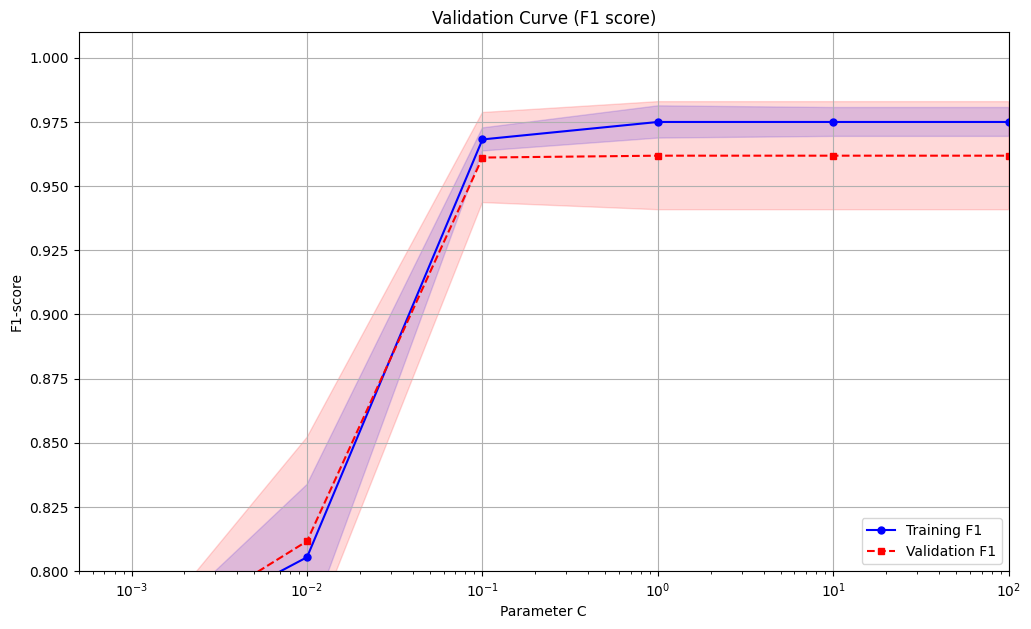

In [243]:
train_mean = np.mean(train_scores, axis=1)
train_std = np.std(train_scores, axis=1)
test_mean = np.mean(test_scores, axis=1)
test_std = np.std(test_scores, axis=1)

fig=plt.figure(figsize=(12,7))
ax = fig.add_subplot()
ax.plot(range_C, train_mean,
         color='blue', marker='o',
         markersize=5, label='Training F1')

ax.fill_between(range_C,
                 train_mean + train_std,
                 train_mean - train_std,
                 alpha=0.15, color='blue')

ax.plot(range_C, test_mean,
         color='red', linestyle='--',
         marker='s', markersize=5,
         label='Validation F1')

ax.fill_between(range_C,
                 test_mean + test_std,
                 test_mean - test_std,
                 alpha=0.15, color='red')

ax.grid()
ax.set_title('Validation Curve (F1 score)')
ax.set_xlabel('Parameter C')
ax.set_ylabel('F1-score')
ax.legend(loc='lower right')
ax.set_ylim([0.8, 1.01])
ax.set_xscale('log')
ax.set_xlim([0.0005,100])

For very small values of the regularization parameter C, both training and validation F1-scores are low, indicating underfitting. As C increases performance improves rapidly and reaches a maximum between 10^-1 and 10^0. After this point, both validation and training performances plateaus with a very small gap between the two, suggesting no substantial gain in generalization and no evident overfitting.

The preference for a relatively small C reflects the need for stronger regularization in a small sample-size setting.

## Final model evaluation 

### Confusion Matrix

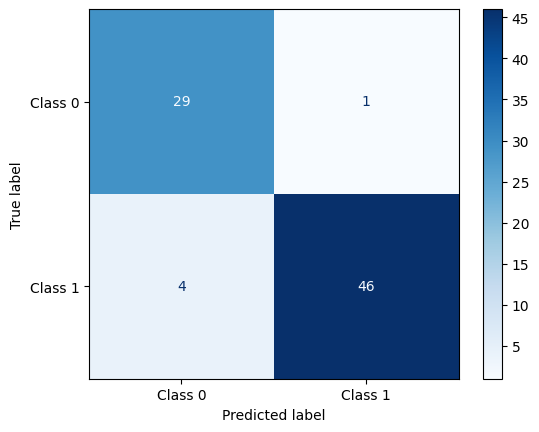

In [246]:
ConfusionMatrixDisplay.from_estimator(
    cls,
    X_sc_test,
    y_sc_test,
    display_labels=['Class 0', 'Class 1'],
    cmap='Blues',
    values_format='d'
)

According to the final confusion matrix, almost all negative instances are correclty classified, yielding near perfect specificity, and the majority of the positive cases (46 out of 50) are correctly identified, resulting in high sensitivity. Overall, these results are consistent with the previous evaluation metrics and indicate good generalization on the available data. However, given the small sample-size, the observed classification performance should be interpreted with caution when considering generalization to broader populations.

<a style='text-decoration:none;line-height:16px;display:flex;color:#5B5B62;padding:10px;justify-content:end;' href='https://deepnote.com?utm_source=created-in-deepnote-cell&projectId=beb37f11-dc99-4a3b-a4a0-ee2700072a5a' target="_blank">

Created in <span style='font-weight:600;margin-left:4px;'>Deepnote</span></a>